# Preparation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math
from PIL import Image

# 1st Practicum - Convolution without Any Libraries

In [3]:
def convolution2d(
    image: np.ndarray, 
    kernel: np.ndarray, 
    stride: int = 1, 
    padding: int = 0
) -> np.ndarray:
    """
    Perform 2D convolution on an image with a given kernel.
    
    Args:
        image: Input image as numpy array (H x W) or (H x W x C)
        kernel: Convolution kernel as numpy array (K_H x K_W)
        stride: Step size for convolution (default: 1)
        padding: Number of pixels to pad around the image (default: 0)
    
    Returns:
        Convolved image as numpy array
    """
    # Handle grayscale and color images
    if len(image.shape) == 3:
        # For color images, apply convolution to each channel
        result = np.zeros_like(image)
        for c in range(image.shape[2]):
            result[:,:,c] = convolution2d(image[:,:,c], kernel, stride, padding)
        return result
    
    # Get dimensions
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    # Apply padding
    if padding > 0:
        padded_image = np.pad(image, padding, mode='constant', constant_values=0)
    else:
        padded_image = image
    
    # Calculate output dimensions
    output_height = (padded_image.shape[0] - kernel_height) // stride + 1
    output_width = (padded_image.shape[1] - kernel_width) // stride + 1
    
    # Initialize output
    output = np.zeros((output_height, output_width))
    
    # Perform convolution
    for i in range(0, output_height):
        for j in range(0, output_width):
            # Extract region of interest
            start_i = i * stride
            start_j = j * stride
            roi = padded_image[
                start_i:start_i + kernel_height,start_j:start_j + kernel_width
            ]
            
            # Element-wise multiplication and sum
            output[i, j] = np.sum(roi * kernel)
    
    return output

In [13]:
kernel_size = 21
sigma = math.sqrt(kernel_size)

kernels = {
    'sharpen' : np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ]),
    'emboss' : np.array([
        [-2, -1, 0],
        [-1, 1, 1],
        [0, 1, 2]
    ]),
    'left-sobel-edge' : np.array([
        [1, 0, -1],
        [2, 1, -2],
        [1, 0, -1]
    ]),
    'canny-edge' : np.array([
        [-1, -1, -1],
        [-1, 8, -1],
        [-1, -1, -1]
    ]),
    'gaussian' : cv2.getGaussianKernel(kernel_size, sigma).dot(cv2.getGaussianKernel(kernel_size, sigma).T)
}

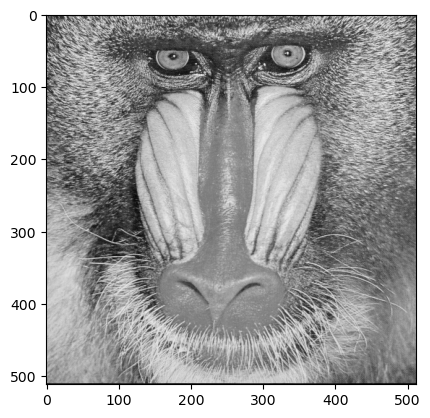

In [6]:
img = cv2.imread('../assets/mandrill.tiff')

if img is None:
    raise Exception('Image is not found!')

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap='gray')
plt.show()

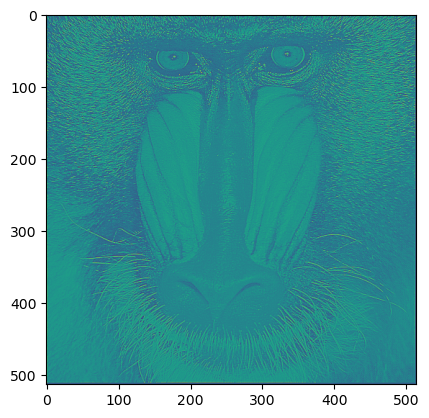

In [11]:
result_conv = convolution2d(
    image=img_gray,   
    kernel=kernels['sharpen'], 
    stride=1, 
    padding=2
)

plt.imshow(result_conv)
plt.show()

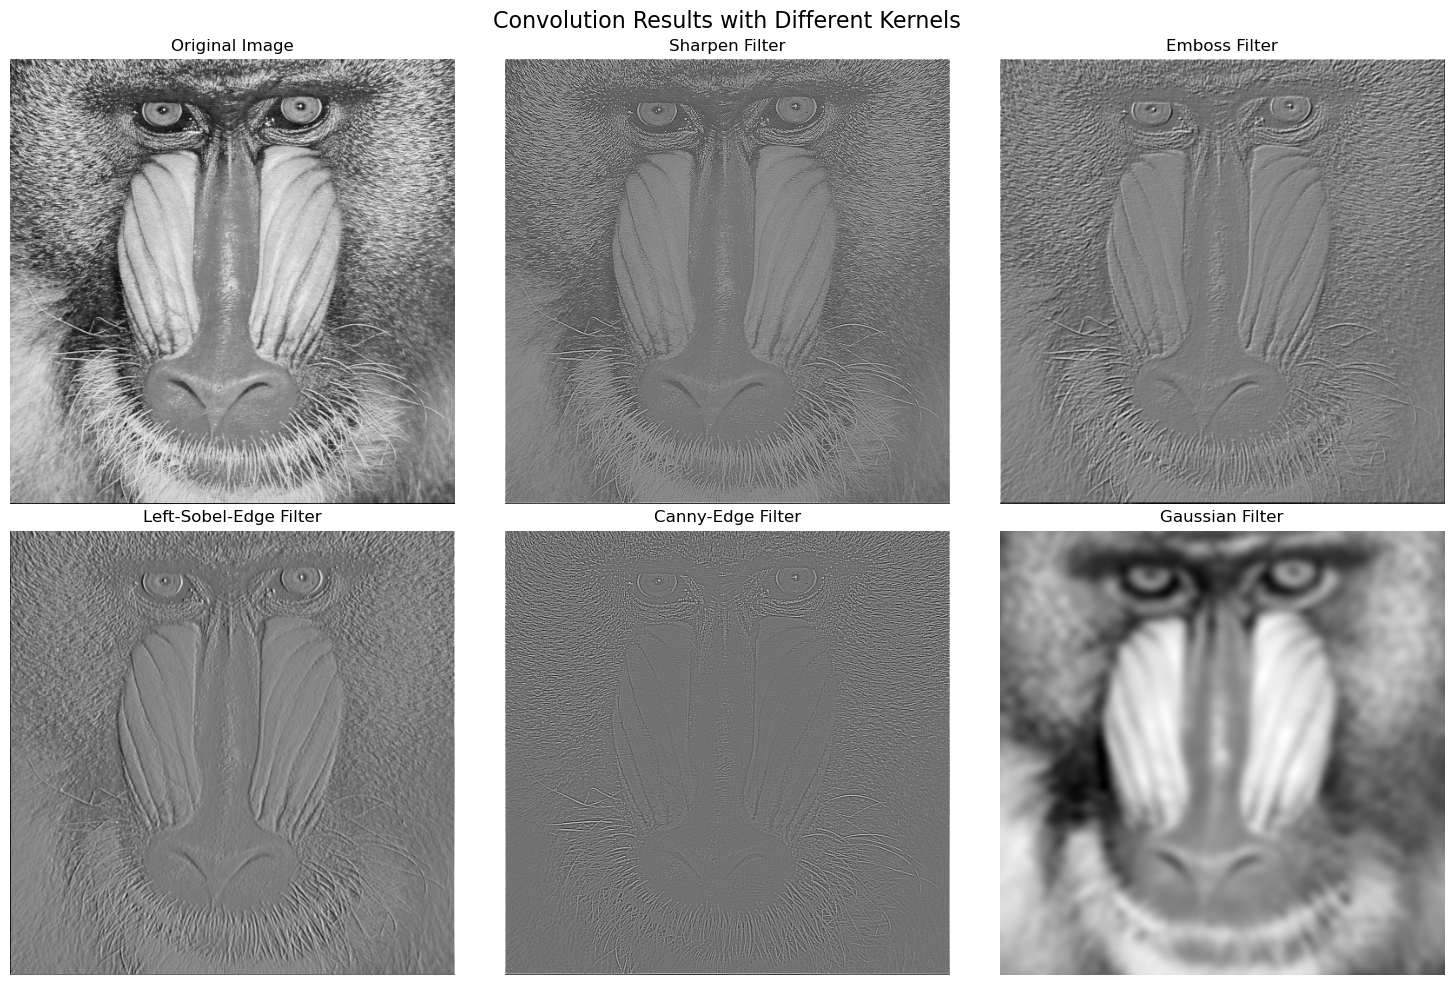

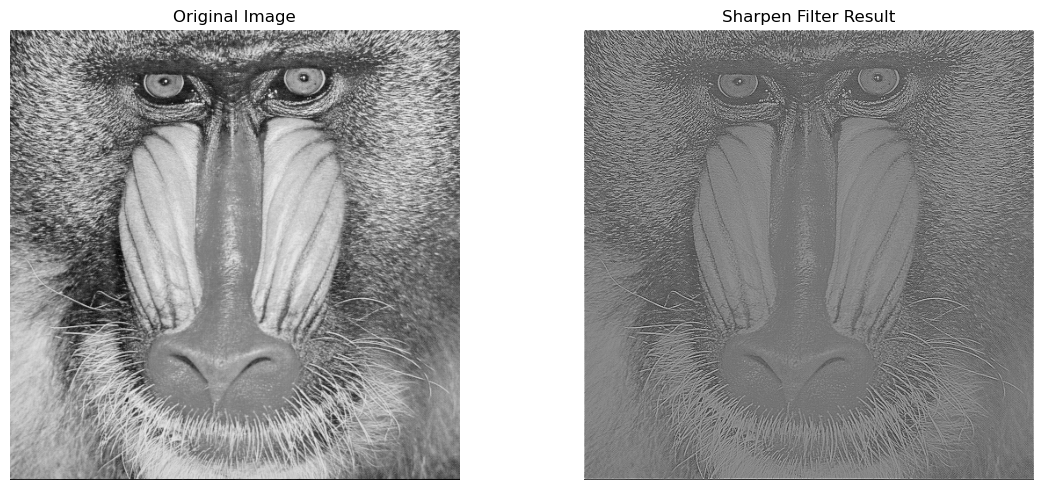

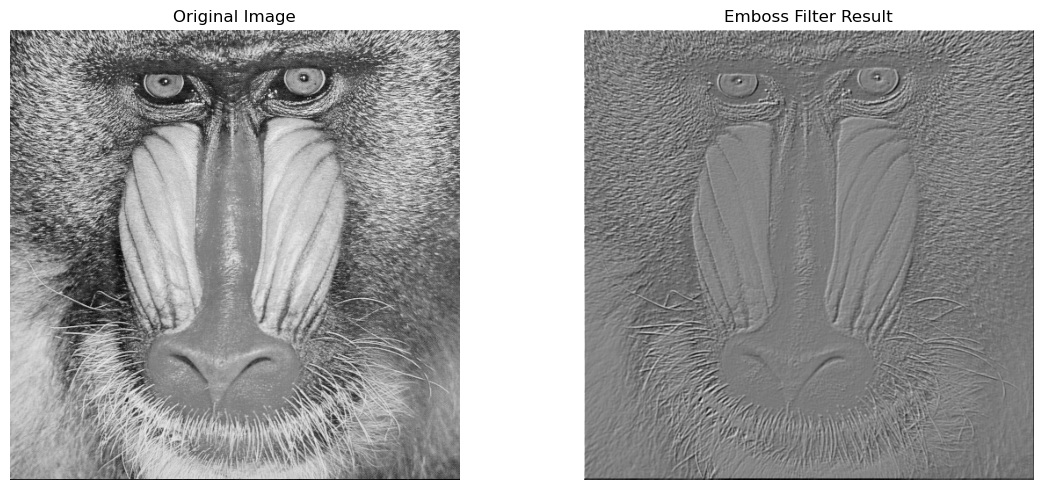

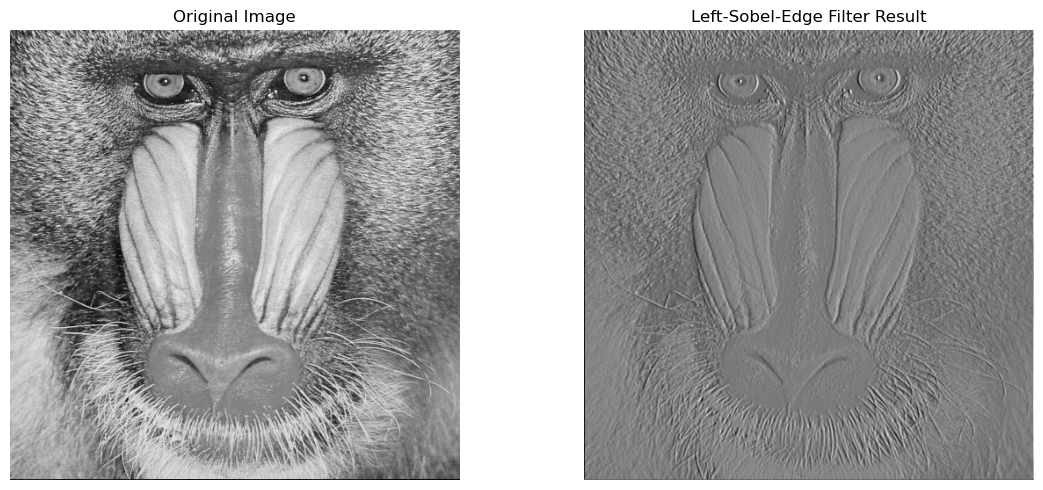

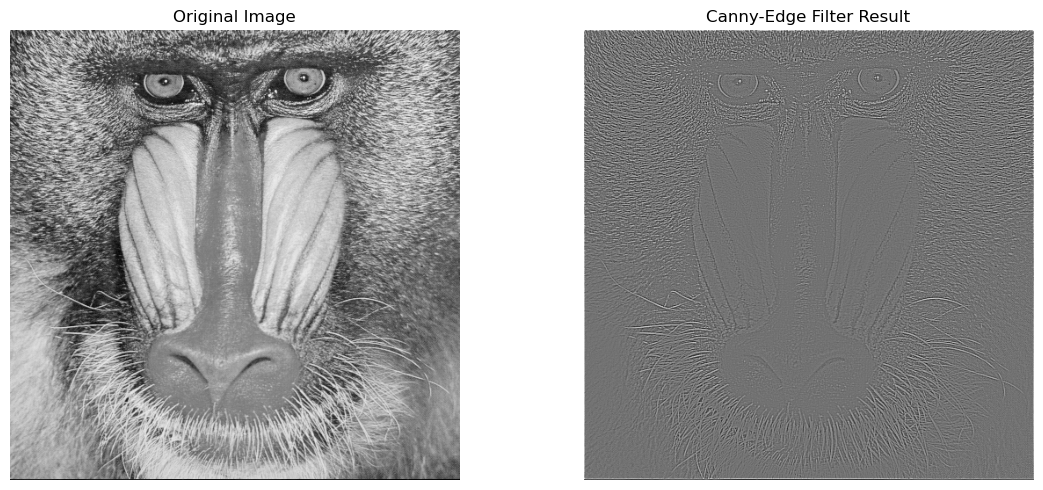

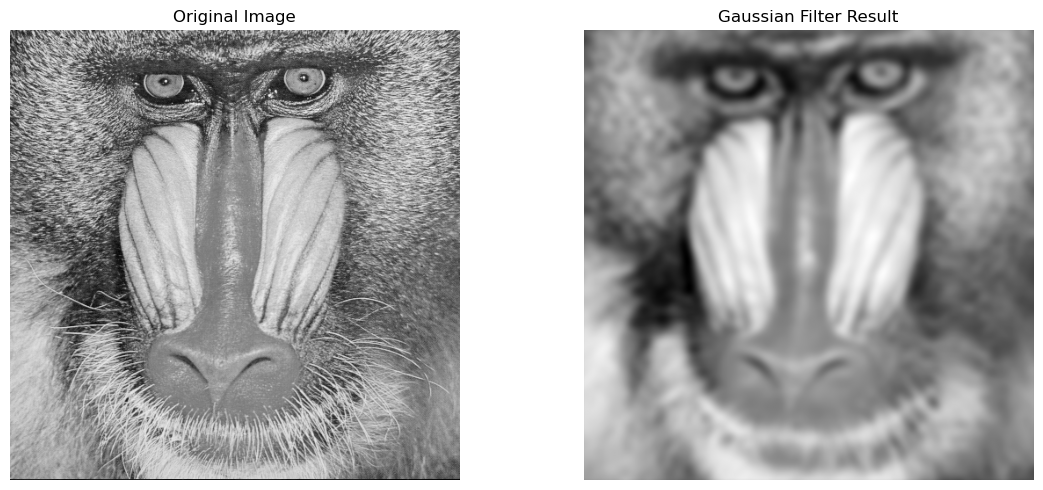

In [16]:
# Display original image and convolution results from all kernels
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Convolution Results with Different Kernels', fontsize=16)

# Original image
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Apply convolution with each kernel and display
kernel_names = list(kernels.keys())
positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

for i, (kernel_name, position) in enumerate(zip(kernel_names, positions)):
    if i < len(kernel_names):
        # Apply convolution
        result = convolution2d(
            image=img_gray,
            kernel=kernels[kernel_name],
            stride=1,
            padding=1
        )
        
        # Display result
        row, col = position
        axes[row, col].imshow(result, cmap='gray')
        axes[row, col].set_title(f'{kernel_name.title()} Filter')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Individual detailed view of each kernel result
for kernel_name in kernels.keys():
    result = convolution2d(
        image=img_gray,
        kernel=kernels[kernel_name],
        stride=1,
        padding=1
    )
    
    plt.figure(figsize=(12, 5))
    
    # Original
    plt.subplot(1, 2, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    # Convolved result
    plt.subplot(1, 2, 2)
    plt.imshow(result, cmap='gray')
    plt.title(f'{kernel_name.title()} Filter Result')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 2nd Practicum